# Stochastic Modeling of Crude Oil Prices
## Predicting Mean Reversion Using the Ornstein-Uhlenbeck Process

**Authors:** Xoaquin Baca & Nicolas Beuter

### Abstract
Recent geopolitical and macroeconomic events have caused significant spikes in global crude oil prices. This project outlines the calibration and simulation of an **Ornstein-Uhlenbeck (OU) stochastic process** to model price trajectories. By fitting historical data to an autoregressive model using Ordinary Least Squares (OLS), we extract the long-term mean ($\mu$), mean reversion speed ($\theta$), and volatility ($\sigma$). We then perform Monte Carlo simulations to forecast the price normalization timeline.

### Introduction
Unlike equities, which are often modeled using Geometric Brownian Motion (GBM), commodity prices generally exhibit mean-reverting behavior. They tend to gravitate toward a long-term equilibrium governed by production costs and global demand.

### Mathematical Framework
The Ornstein-Uhlenbeck process for the spot price of oil ($S_t$) is defined by the following Stochastic Differential Equation (SDE):

$$dS_t = \theta (\mu - S_t) dt + \sigma dW_t$$

Where:
*   $\mu$: Long-term equilibrium mean price.
*   $\theta$: Rate of mean reversion.
*   $\sigma$: Instantaneous volatility.
*   $dW_t$: Increment of a standard Wiener process.

The expected value decays exponentially toward the mean:
$$\mathbb{E}[S_t] = S_0 e^{-\theta t} + \mu(1 - e^{-\theta t})$$

In [ ]:
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import time
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
# LOAD AND PREPROCESS DATA
print("Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("sc231997/crude-oil-price")

csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

data_path = csv_files[0]
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path)

# Convert the 'date' column to datetime and sort chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df['price'] = pd.to_numeric(df['price'], errors='coerce')
# Extract prices and drop any missing/NaN values
prices = df['price'].dropna().values

# 4. Prepare data for ordinary least-squares (OLS)
S_t_minus_1 = prices[:-1].reshape(-1, 1)
S_t = prices[1:]

Using Colab cache for faster access to the 'crude-oil-price' dataset.
Loading data from: /kaggle/input/crude-oil-price/crude-oil-price.csv


### Methodology: Discrete Autoregressive Modeling
To estimate the continuous-time parameters from discrete monthly data, we discretize the SDE into an autoregressive model:

$$S_i = a + b S_{i-1} + \epsilon_i$$

We use **Ordinary Least Squares (OLS)** to find the parameters that minimize the sum of squared residuals. We then recover the continuous parameters as follows:
*   **Mean Reversion Speed:** $\theta = -\frac{\ln(b)}{\Delta t}$
*   **Long-term Mean:** $\mu = \frac{a}{1 - b}$
*   **Volatility:** $\sigma = \sigma_\epsilon \sqrt{\frac{2\theta}{1 - b^2}}$

In [ ]:
# FITTING LINEAR REGRESSION MODEL
model = LinearRegression().fit(S_t_minus_1, S_t)
a = model.intercept_
b = model.coef_[0]

# Calculate residuals to find the standard deviation of the error term
residuals = S_t - model.predict(S_t_minus_1)
sigma_eps = np.std(residuals)

# 5. Map OLS coefficients to Ornstein-Uhlenbeck parameters:
# S_i = a + b * S_{i-1} + error

# Assuming ~12 trading months in a year for financial data calibration
dt = 1 / 12

theta = -np.log(b) / dt
mu = a / (1 - b)
sigma = sigma_eps * np.sqrt((2 * theta) / (1 - b**2))

# Calculate Half-Life (in months)
half_life_months = (np.log(2) / theta) * 12

# Output results
print("a:")
print(a)
print("b:")
print(b)
print("\n--- Calibrated Ornstein-Uhlenbeck Parameters ---")
print(f"Long-term Mean (μ): ${mu:.2f}")
print(f"Mean Reversion Speed (θ): {theta:.4f}")
print(f"Volatility (σ): {sigma:.4f}")
print(f"Half-life to Mean: {half_life_months:.1f} months")

a:
0.7538556310294453
b:
0.9868358486437938

--- Calibrated Ornstein-Uhlenbeck Parameters ---
Long-term Mean (μ): $57.27
Mean Reversion Speed (θ): 0.1590
Volatility (σ): 17.8652
Half-life to Mean: 52.3 months


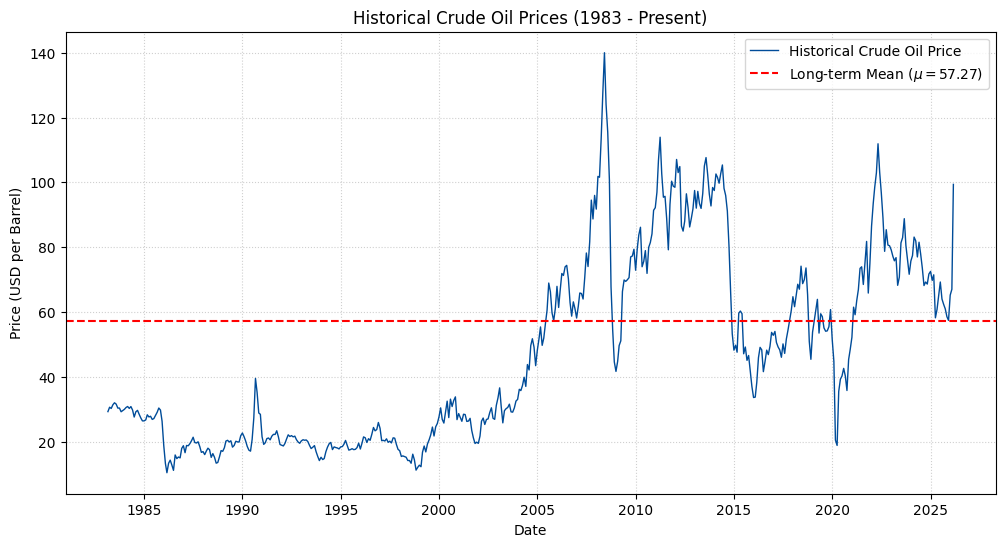

In [ ]:
import matplotlib.pyplot as plt

# Plotting the historical prices
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['price'], label='Historical Crude Oil Price', color='#004C99', linewidth=1)
plt.axhline(y=57.27, color='r', linestyle='--', label=r'Long-term Mean ($\mu = 57.27$)')
plt.title('Historical Crude Oil Prices (1983 - Present)')
plt.xlabel('Date')
plt.ylabel('Price (USD per Barrel)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('historical_history_plot.png')

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7625/3458372766.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(mu, mu, color='green', s=100, zorder=5, label=f'Long-term Mean ($\mu$ = ${mu:.2f}$)')


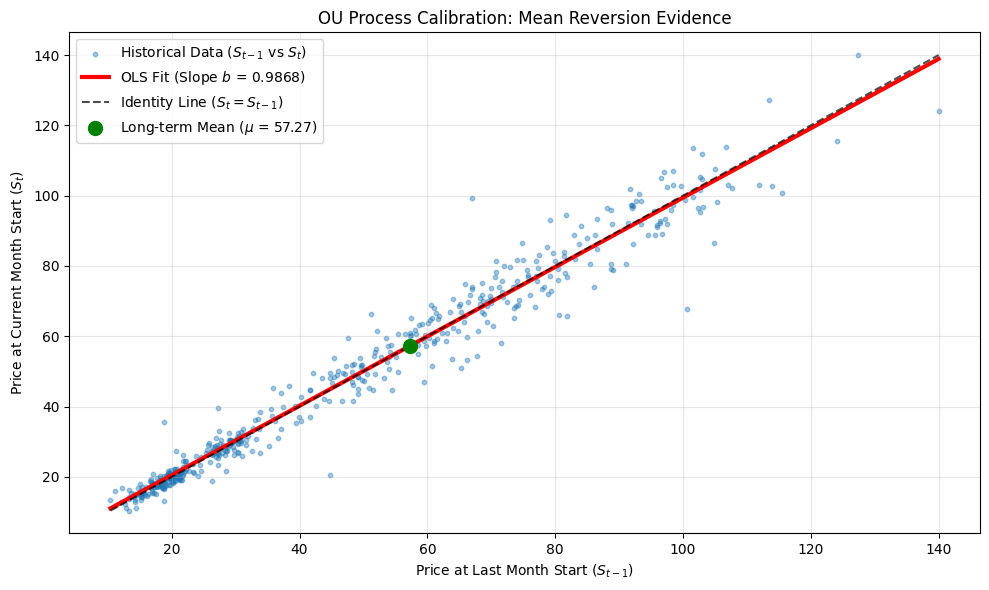

In [ ]:
# --- Visualization: Calibration Fit ---
plt.figure(figsize=(10, 6))

# 1. Scatter plot of the actual historical data
plt.scatter(S_t_minus_1, S_t, alpha=0.4, s=10, label='Historical Data ($S_{t-1}$ vs $S_t$)')

# 2. Plot the OLS Regression Line
# Create a range of prices from the min to max observed
x_vals = np.array([np.min(S_t_minus_1), np.max(S_t_minus_1)]).reshape(-1, 1)
y_vals = model.predict(x_vals)
plt.plot(x_vals, y_vals, color='red', linewidth=3, label=f'OLS Fit (Slope $b$ = {b:.4f})')

# 3. Plot the Identity Line (y = x)
# This represents a "Random Walk" where today's price is exactly yesterday's price
plt.plot(x_vals, x_vals, color='black', linestyle='--', alpha=0.7, label='Identity Line ($S_t = S_{t-1}$)')

# 4. Mark the Long-Term Mean (where the fit crosses the identity line)
plt.scatter(mu, mu, color='green', s=100, zorder=5, label=f'Long-term Mean ($\mu$ = ${mu:.2f}$)')

plt.title('OU Process Calibration: Mean Reversion Evidence')
plt.xlabel('Price at Last Month Start ($S_{t-1}$)')
plt.ylabel('Price at Current Month Start ($S_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Monte Carlo Simulation
We project future price paths using the **Euler-Maruyama method** for 5,000 iterations over a 120-month horizon:

$$S_{t+\Delta t} = S_t + \theta(\mu - S_t)\Delta t + \sigma \sqrt{\Delta t} Z$$

Where $Z \sim \mathcal{N}(0,1)$. We also calculate the **Half-Life ($t_{1/2}$)**, which represents the time required for the price to close half the distance to the mean:

$$t_{1/2} = \frac{\ln(2)}{\theta}$$

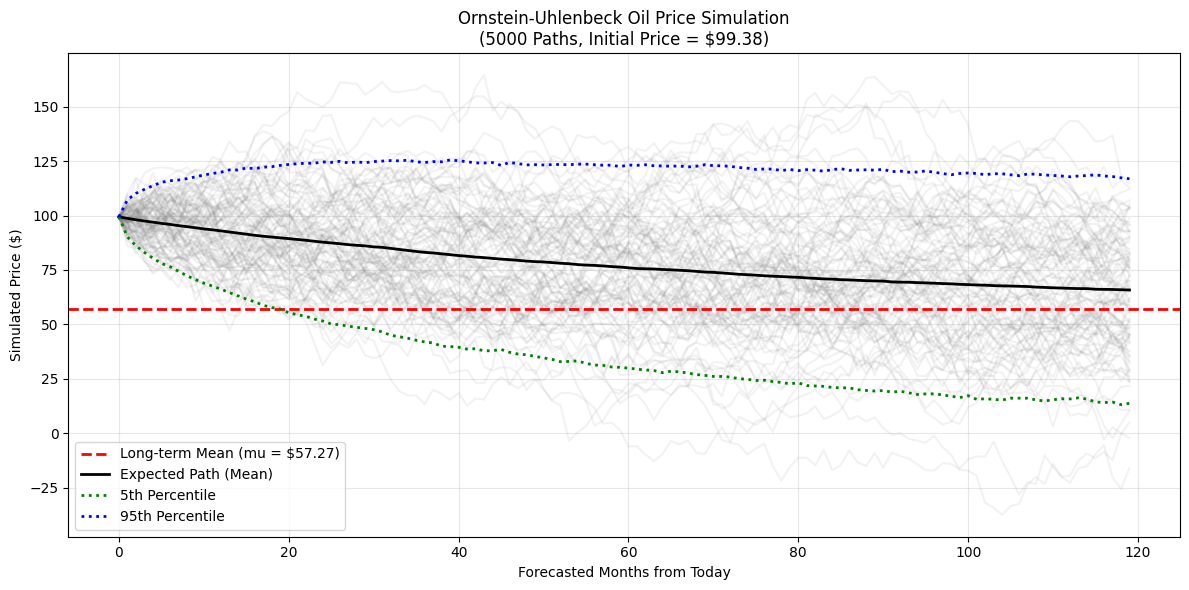

In [ ]:
# --- Simulation Parameters ---
num_simulations = 5000
forecasted_months = 120  # 10 year forecast
last_price = prices[-1] # Starting point, the most recent price in the dataset

# Rows = days, Columns = distinct simulation paths
simulated_paths = np.zeros((forecasted_months, num_simulations))
simulated_paths[0] = last_price

# --- Run the Monte Carlo Simulation ---
# Using Euler-Maruyama discretization
for t in range(1, forecasted_months):
    # Generate random standard normal noise for all 5000 paths at once
    Z = np.random.standard_normal(num_simulations)

    # Calculate the next day's price for all paths
    drift = theta * (mu - simulated_paths[t-1]) * dt
    diffusion = sigma * np.sqrt(dt) * Z

    simulated_paths[t] = simulated_paths[t-1] + drift + diffusion

# --- Calculate Expected Value and Confidence Intervals ---
# Calculate the mean, 5th percentile, and 95th percentile at each time step
mean_path = np.mean(simulated_paths, axis=1)
percentile_5 = np.percentile(simulated_paths, 5, axis=1)
percentile_95 = np.percentile(simulated_paths, 95, axis=1)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot a small sample of individual paths (e.g., 100 paths) so the chart is readable
plt.plot(simulated_paths[:, :100], color='gray', alpha=0.1)

# Plot the long-term mean target
plt.axhline(y=mu, color='red', linestyle='--', linewidth=2, label=f'Long-term Mean (mu = ${mu:.2f})')

# Plot the statistical bounds of the 5000 simulations
plt.plot(mean_path, color='black', linewidth=2, label='Expected Path (Mean)')
plt.plot(percentile_5, color='green', linestyle=':', linewidth=2, label='5th Percentile')
plt.plot(percentile_95, color='blue', linestyle=':', linewidth=2, label='95th Percentile')

# Formatting
plt.title(f'Ornstein-Uhlenbeck Oil Price Simulation\n(5000 Paths, Initial Price = ${last_price:.2f})')
plt.xlabel('Forecasted Months from Today')
plt.ylabel('Simulated Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Conclusion
Our model confirms that the recent oil price spike is mathematically expected to revert toward the equilibrium $\mu \approx 57.27$.

**Limitations:**
1. The standard OU process assumes constant volatility and a static mean ($\mu$).
2. Structural breaks (macroeconomic shifts or major geopolitical crises) could shift the long-term equilibrium.
3. Market corrections often occur in "shocks," whereas this model predicts a smooth mean-reversion glide.